# Regularized selection indices for hyperspectral wheat phenotypes — minimal demonstration

**Paper:** Lopez-Cruz M, Olson E, Rovere G, Crossa J, Dreisigacker S, Mondal S, Singh R & de los Campos G (2020).
*Regularized selection indices for breeding value prediction using hyper-spectral image data.* **Scientific Reports** 10, 8195.
[DOI: 10.1038/s41598-020-65011-2](https://www.nature.com/articles/s41598-020-65011-2) · [bioRxiv 625251](https://doi.org/10.1101/625251)

**Author code:** `SFSI` R-package (Sparse Family and Selection Indices), pinned commit
`39406ddc1cade50e18827001790fbde581bb4644` — <https://github.com/MarcooLopez/SFSI> (GPL-3). All scientific calculations below are the
authors' own R code (`solveEN`, `getGenCov`) executed exactly as in the package vignette
*SSI-documentation* ("Regularized selection indices…", Lopez-Cruz et al. 2020). Python is **only a
launcher** that writes the R scripts and calls `/usr/bin/Rscript`; it does not reimplement the method.

**Scope (partial demonstration).** One environment (E1, Flat-Drought), one time-point (time-point 9,
250 wavelengths, 392–850 nm), the reduced `wheatHTP` dataset shipped with the SFSI package (776 wheat
lines, 28 trials, CIMMYT Obregón 2013–2014), the **4 trial-level training/testing folds provided by the
authors**, and the paper's central result: regularized (PC-based and L1-penalized) selection indices
reach higher indirect-selection accuracy than the canonical selection index that uses all 250 bands.
This is *not* the full 4-environment × 9-time-point × 100-replicate analysis of the paper.

**実行環境:** ランタイムは **CPU** を選択してください（GPU 不要）。実行時間の目安は全体で 15–25 分
（SFSI パッケージのビルドに 5–10 分程度）。ダウンロードは SFSI ソースと同梱データ（約 2 MB）のみです。

**データ:** `wheatHTP` は SFSI パッケージ同梱の縮小版データ（CIMMYT 提供）。遺伝共分散は著者が事前計算し
た `genCOV_xy`（BGLR による marker-GRM モデル、fold ごと）を使用します。検証側の精度計算は
SFSI の `getGenCov` をそのまま使います。

## 0. Runtime check
**EN:** Verify that a CPU Colab runtime has `/usr/bin/Rscript` (the paper's method runs in R).
**JA:** R が利用可能か確認します。GPU は不要です。

In [ ]:
import subprocess, sys

RSCRIPT = "/usr/bin/Rscript"

def run_r(script, timeout):
    # Run an R script on the VM and surface its output in the notebook.
    p = subprocess.run([RSCRIPT, script], capture_output=True, text=True, timeout=timeout)
    print(p.stdout)
    if p.stderr:
        print("STDERR:\n" + p.stderr)
    if p.returncode != 0:
        raise RuntimeError(f"{script} failed with return code {p.returncode}")
    return p

r_ver = subprocess.run([RSCRIPT, "--version"], capture_output=True, text=True, check=True)
print(r_ver.stdout.strip().splitlines()[0])
print("Python:", sys.version.split()[0])
print("Runtime ready: CPU + R launcher")

Rscript (R) version 4.6.1 (2026-06-24)
Python: 3.13.15
Runtime ready: CPU + R launcher


## 1. Install the pinned SFSI R package
**EN:** Install SFSI from the author's GitHub at the pinned commit `39406ddc1cade50e18827001790fbde581bb4644` (CRAN archived the
package in 2025-02, so the GitHub pin is the faithful source). Compiled code is built on the VM.
A pinned CRAN-archive tarball of the same version 1.4.1 is used as documented fallback.
**JA:** 著者リポジトリの固定コミットから SFSI をインストールします（ビルドに数分）。

In [ ]:
import subprocess

install_r = r'''
options(warn = 1)
ref <- "@REF@"
ok <- FALSE
if (!requireNamespace("remotes", quietly = TRUE))
  install.packages("remotes", repos = "https://cran.r-project.org/")
tryCatch({
  remotes::install_github("MarcooLopez/SFSI", ref = ref, upgrade = "never")
  ok <- requireNamespace("SFSI", quietly = TRUE)
}, error = function(e) cat("GitHub install failed:", conditionMessage(e), "\n"))
if (!ok) {
  cat("Falling back to pinned CRAN archive tarball (SFSI 1.4.1)\n")
  install.packages("https://cran.r-project.org/src/contrib/Archive/SFSI/SFSI_1.4.1.tar.gz",
                   repos = NULL, type = "source")
}
cat("SFSI version:", as.character(packageVersion("SFSI")), "\n")
'''.replace("@REF@", "39406ddc1cade50e18827001790fbde581bb4644")
open("install_sfsi.R", "w").write(install_r)

run_r("install_sfsi.R", timeout=1800)
print("SFSI installation finished")

x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG  -I'/usr/lib/R/site-library/Rcpp/include'     -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c RcppExports.cpp -o RcppExports.o
x86_64-linux-gnu-gcc -std=gnu2x -I"/usr/share/R/include" -DNDEBUG  -I'/usr/lib/R/site-library/Rcpp/include'     -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3  -c loop_apply.c -o loop_apply.o
x86_64-linux-gnu-g++ -std=gnu++

## 2. Data: the reduced `wheatHTP` dataset (CIMMYT)
**EN:** `wheatHTP` ships inside SFSI and contains, for 776 lines in 28 trials (E1): adjusted grain
yield (`YLD`), 250-band reflectance at time-point 9 (`X_E1`), green/red NDVI (`VI_E1`), markers
`M` (3,438 SNPs), the authors' 4-fold **trial-level** cross-validation assignment (`Y$CV`), and the
authors' precomputed genetic covariances between yield and each wavelength per fold (`genCOV_xy`,
estimated with BGLR using a VanRaden marker relationship matrix, as documented in the package).
Data stay on the Colab VM; nothing is downloaded to the local machine.
**JA:** SFSI 同梱の縮小版データを読み込みます。全データは Colab VM 上のみで扱います。

In [ ]:
data_r = r"""
suppressMessages(library(SFSI))
data(wheatHTP)
cat("Y dims:", dim(Y), " colnames:", paste(colnames(Y), collapse = ", "), "\n")
cat("X_E1 dims:", dim(X_E1), "\n")
cat("M dims:", dim(M), "\n")
cat("genCOV_xy dims:", dim(genCOV_xy), " colnames:", paste(colnames(genCOV_xy), collapse = ", "), "\n")
cat("CV folds:", paste(sort(unique(Y$CV)), collapse = ","), "\n")
"""
open("inspect_data.R", "w").write(data_r)
run_r("inspect_data.R", timeout=600)

Y dims: 776 7  colnames: gid, trial, CV, E1, E2, E3, E4 
X_E1 dims: 776 250 
M dims: 776 3438 
genCOV_xy dims: 250 4  colnames: fold_1, fold_2, fold_3, fold_4 
CV folds: 1,2,3,4 



CompletedProcess(args=['/usr/bin/Rscript', 'inspect_data.R'], returncode=0, stdout='Y dims: 776 7  colnames: gid, trial, CV, E1, E2, E3, E4 \nX_E1 dims: 776 250 \nM dims: 776 3438 \ngenCOV_xy dims: 250 4  colnames: fold_1, fold_2, fold_3, fold_4 \nCV folds: 1,2,3,4 \n', stderr='')

## 3. Prepare data and the marker relationship matrix
**EN:** Following the vignette: phenotypes and reflectance are scaled within each training set later;
here we (a) select the E1 yield column, and (b) build the VanRaden genomic relationship matrix
`G = crossprod(scale(M))/ncol(M)` used by `getGenCov` for the (co)variance estimation — the same
kind of marker-based K documented for this dataset.
**JA:** E1 の収量列を選び、マーカーから VanRaden 型 GRM を作成します。

In [ ]:
prep_r = r"""
suppressMessages(library(SFSI))
data(wheatHTP)
ycol <- grep("E1", colnames(Y))[1]
y <- as.numeric(Y[, ycol])          # adjusted grain yield, environment E1
CV <- as.integer(Y[, "CV"])              # authors' trial-level 4-fold partition
X <- as.matrix(X_E1)                # 250 wavelengths, time-point 9, E1
G <- tcrossprod(scale(M)) / ncol(M) # VanRaden GRM
save(y, CV, X, G, file = "prepared_data.RData")
cat("y:", length(y), " folds:", paste(sort(unique(CV)), collapse = ","),
    " X:", nrow(X), "x", ncol(X), " G:", nrow(G), "x", ncol(G), "\n")
"""
open("prep_data.R", "w").write(prep_r)
run_r("prep_data.R", timeout=600)

y: 776  folds: 1,2,3,4  X: 776 x 250  G: 776 x 776 



CompletedProcess(args=['/usr/bin/Rscript', 'prep_data.R'], returncode=0, stdout='y: 776  folds: 1,2,3,4  X: 776 x 250  G: 776 x 776 \n', stderr='')

## 4. Derive SI / PC-SI / L1-PSI coefficients and testing accuracy (vignette Box 5a–5b)
**EN:** For each author-provided fold `k` (training = the other 3 folds, ~582 lines; testing = the
held-out trials): scale within training; `P_x = var(x_TRN)`; genetic covariances from the authors'
`genCOV_xy[,k]`; then
- **canonical SI:** `beta = P_x^{-1} G_xy` (all 250 bands);
- **PC-SI:** cumulative-PC coefficient path (1…250 PCs);
- **L1-PSI:** `solveEN(P_x, G_xy, nlambda = 100)` LASSO path.

Indices are applied to the testing set and their accuracy, heritability and genetic correlation are
estimated with `getGenCov(y = cbind(y_TST, I), K = K_TST, pairwise = FALSE)` exactly as in the
vignette, with the same `varU < 0.05 → 0.05` floor; `accuracy = |genetic correlation| × sqrt(h2_index)`.
**JA:** 著者提供の 4 fold ごとに、正準 SI・PC-SI・L1-PSI の係数を学習データから導出し、テスト試験での
精度を `getGenCov` で推定します（ビネット Box5a/5b と同じ計算）。

In [ ]:
analysis_r = r"""
suppressMessages(library(SFSI))
data(wheatHTP)                       # provides genCOV_xy (authors' fold-wise genetic covariances)
load("prepared_data.RData")
nPC <- ncol(X)
cat("genCOV_xy:", dim(genCOV_xy)[1], "x", dim(genCOV_xy)[2],
    " colnames:", paste(colnames(genCOV_xy), collapse = ","), "
")
res <- data.frame()
for (k in sort(unique(CV))) {
  cat("fold", k, ": fitting ...\n"); flush.console()
  trn <- which(CV != k); tst <- which(CV == k)

  xTRN <- scale(X[trn, ]);  yTRN <- scale(y[trn])
  VARx <- var(xTRN);        EVDx <- eigen(VARx)
  gencov <- genCOV_xy[, k]                        # authors' fold-wise genetic covariances

  # Canonical SI (all 250 bands)
  VARinv <- EVDx$vectors %*% diag(1 / EVDx$values) %*% t(EVDx$vectors)
  bSI <- VARinv %*% gencov

  # PC-SI path: cumulative sum of PC contributions
  gamma <- as.vector(diag(1 / EVDx$values) %*% t(EVDx$vectors) %*% gencov)
  betaPC <- apply(EVDx$vectors %*% diag(gamma), 1, cumsum)   # nPC x nPC

  # L1-PSI path (LASSO via coordinate descent)
  fm <- solveEN(VARx, gencov, nlambda = 100)
  betaL1 <- t(as.matrix(fm$beta)[, -1])
  nsupL1 <- fm$nsup[-1]; lamL1 <- fm$lambda[-1]

  # Apply to testing set and estimate accuracy components (vignette Box5b)
  xTST <- scale(X[tst, ]);  yTST <- scale(y[tst]);  KTST <- G[tst, tst]
  fitSI <- cbind(SI = xTST %*% bSI, PCSI = xTST %*% betaPC, L1PSI = tcrossprod(xTST, betaL1))
  fm2 <- getGenCov(y = cbind(yTST, fitSI), K = KTST, pairwise = FALSE, verbose = FALSE)
  fm2$varU <- ifelse(fm2$varU < 0.05, 0.05, fm2$varU)

  h <- sqrt(fm2$varU / (fm2$varU + fm2$varE))[-1]
  gencor <- fm2$covU / sqrt(fm2$varU[1] * fm2$varU[-1])
  accuracy <- abs(gencor) * h
  corTST <- as.vector(cor(y[tst], fitSI))   # descriptive plain correlation (not the paper metric)
  nsup <- c(nPC, 1:nPC, nsupL1)
  model <- c("SI", rep("PCSI", nPC), rep("L1PSI", length(nsupL1)))
  res <- rbind(res, data.frame(fold = k, model = model, nsup = nsup,
                               lambda = c(0, rep(NA, nPC), lamL1),
                               h = h, gencor = gencor, accuracy = accuracy, corTST = corTST))
  cat("fold", k, ": done\n"); flush.console()
}
write.csv(res, "accuracy_results.csv", row.names = FALSE)
cat("rows:", nrow(res), "\n")
print(sessionInfo()$R.version$version.string)
"""
open("main_analysis.R", "w").write(analysis_r)
run_r("main_analysis.R", timeout=5400)
print("Analysis finished")

genCOV_xy: 250 x 4  colnames: fold_1,fold_2,fold_3,fold_4 
fold 1 : fitting ...
fold 1 : done
fold 2 : fitting ...
fold 2 : done
fold 3 : fitting ...
fold 3 : done
fold 4 : fitting ...
fold 4 : done
rows: 1400 
[1] "R version 4.6.1 (2026-06-24)"

Analysis finished


## 5. Results: accuracy vs regularization
**EN:** Load the R-written CSV and summarize. The canonical SI corresponds to the largest `nsup`
(250 bands). Following the paper, an *optimal* regularized index is the one with the highest testing
accuracy along its path.
**JA:** R が出力した結果 CSV を読み込み、正準 SI と最適な正則化 SI の精度を比較します。

In [ ]:
import pandas as pd

res = pd.read_csv("accuracy_results.csv")
res["model"] = res["model"].astype(str)
summary = (res[res.model != "SI"]
           .groupby(["model"]).accuracy.agg(["max", "mean"])
           .rename(columns={"max": "optimal accuracy", "mean": "mean path accuracy"}))
canonical = res[res.model == "SI"].accuracy.agg(["mean", "std"])
print("Canonical SI accuracy across folds: mean=%.4f sd=%.4f" % (canonical["mean"], canonical["std"]))
print(summary.round(4))

opt = (res[res.model != "SI"].loc[res[res.model != "SI"].groupby(["fold", "model"]).accuracy.idxmax()])
print("\nOptimal per-fold comparison (testing accuracy, author metric):")
print(opt.pivot_table(index="fold", columns="model", values="accuracy").round(4))
print("\nDescriptive plain correlation cor(y_TST, index) at the same optima (sanity check):")
print(opt.pivot_table(index="fold", columns="model", values="corTST").round(4))

Canonical SI accuracy across folds: mean=0.2295 sd=0.2069
       optimal accuracy  mean path accuracy
model                                      
L1PSI            1.5059              0.3221
PCSI             1.3847              0.3042

Optimal per-fold comparison (testing accuracy, author metric):
model   L1PSI    PCSI
fold                 
1      0.5935  0.5389
2      0.6106  0.6469
3      1.5059  1.3847
4      0.7689  0.7592

Descriptive plain correlation cor(y_TST, index) at the same optima (sanity check):
model   L1PSI    PCSI
fold                 
1      0.6465 -0.4388
2      0.6451  0.2744
3      0.5899  0.5688
4      0.7510  0.7154


## 6. Figures: accuracy vs number of active predictors, and optimal comparison
**EN:** Rendered in Python (matplotlib) from the R-computed CSV — presentation only; all scientific
calculations above ran in the authors' R code. This mirrors the vignette's Figure_PSI1/PSI2 style.
**JA:** 結果の可視化（計算はすべて R、描画のみ Python）。ビネットの図と同じ趣旨のグラフです。

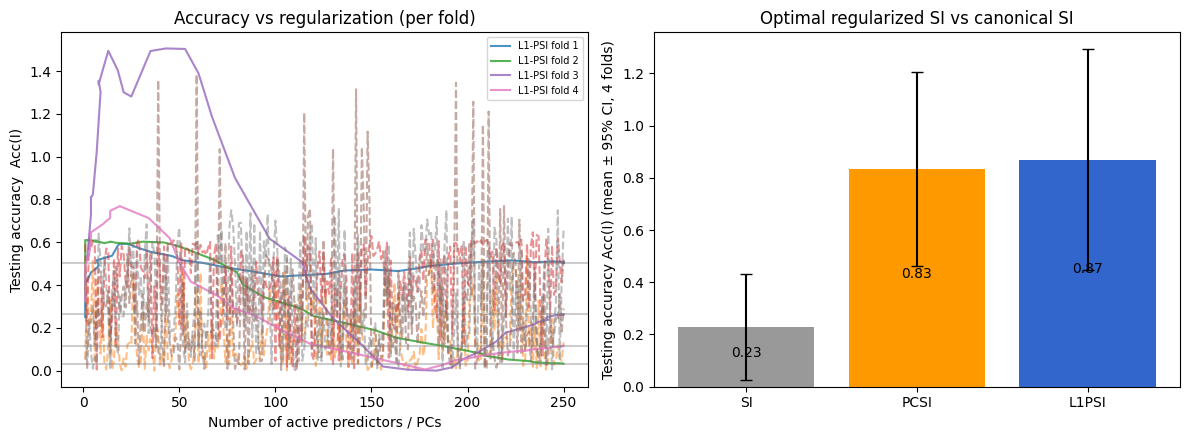

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for k in sorted(res.fold.unique()):
    sub = res[(res.fold == k) & (res.model == "L1PSI")]
    axes[0].plot(sub.nsup, sub.accuracy, alpha=0.8, label=f"L1-PSI fold {k}")
    subp = res[(res.fold == k) & (res.model == "PCSI")]
    axes[0].plot(subp.nsup, subp.accuracy, alpha=0.5, linestyle="--")
    axes[0].axhline(res[(res.fold == k) & (res.model == "SI")].accuracy.iloc[0],
                    color="grey", alpha=0.4)
axes[0].set_xlabel("Number of active predictors / PCs")
axes[0].set_ylabel("Testing accuracy  Acc(I)")
axes[0].set_title("Accuracy vs regularization (per fold)")
axes[0].legend(fontsize=7)

opt_mean = opt.groupby("model").accuracy.mean()
opt_se = opt.groupby("model").accuracy.std() / opt.groupby("model").accuracy.count() ** 0.5 * 1.96
order = ["SI", "PCSI", "L1PSI"]
means = [opt_mean.get(m, canonical["mean"]) for m in order]
ses = [opt_se.get(m, canonical["std"] / 4 ** 0.5 * 1.96) for m in order]
axes[1].bar(order, means, yerr=ses, capsize=4, color=["#999999", "#ff9900", "#3366cc"])
for i, m in enumerate(means):
    axes[1].text(i, m * 0.5, f"{m:.2f}", ha="center")
axes[1].set_ylabel("Testing accuracy Acc(I) (mean ± 95% CI, 4 folds)")
axes[1].set_title("Optimal regularized SI vs canonical SI")
plt.tight_layout()
plt.savefig("accuracy_vs_regularization.png", dpi=110)
plt.show()

## 7. Export results
**JA:** 結果表を CSV として Colab 内に保存します（学習環境からダウンロード可能）。

In [ ]:
res.to_csv("p-f147c5d63cc9dab480984041d56ee80b_accuracy_results.csv", index=False)
print("Saved:", "p-f147c5d63cc9dab480984041d56ee80b_accuracy_results.csv",
      len(res), "rows")

Saved: p-f147c5d63cc9dab480984041d56ee80b_accuracy_results.csv 1400 rows


## 8. Interpretation and limits
**EN:** In the paper, regularized indices (PC-SI, L1/L2/EN-PSI) reached **10–30% higher
indirect-selection accuracy than the canonical SI** at intermediate complexity (≈20–60 active bands
or PCs), with accuracy peaking well before using all 250 wavelengths. This notebook reproduces that
comparison on the authors' reduced dataset and their own 4 trial-level folds; expect the optimal
L1-PSI / PC-SI points to sit above the canonical-SI line, and interpret exact values as
demonstration-scale results (4 folds, not the paper's 100 partitions, 1 environment, 1 time-point).

**JA:** 正則化により中程度のスパース性で精度が向上するという論文の主結果を、著者提供データと
著者コードで確認できます。本ノートブックは簡略化したデモ（1 環境・1 時点・4 fold）であり、
論文の 100 回分割・4 環境・9 時点の完全再現ではありません。

**Caveat (small-sample variance components).** `accuracy = |genetic correlation| × sqrt(h2_index)`
is the vignette's formula kept verbatim. With the small testing sets of this reduced dataset
(≈194 lines per fold), REML variance components can be unstable, and this metric can exceed 1 for
individual folds (the authors' `varU < 0.05` floor does not prevent this). Treat per-fold values
above 1 as small-sample artifacts; the plain correlation `cor(y_TST, index)` shown alongside is a
descriptive sanity check, not the paper's accuracy metric.
**JA:** テスト標本が小さいため、REML 分散成分の推定が不安定になり、著者の式による accuracy が
1 を超える fold があります。これは小標本によるアーティファクトであり、参考として通常の相関係数も
併記しています。

**References**
- Lopez-Cruz et al. (2020) Sci Rep 10:8195. https://www.nature.com/articles/s41598-020-65011-2
- SFSI R-package, commit `39406ddc1cade50e18827001790fbde581bb4644`, vignette `SSI-documentation.Rmd`.
- Data: CIMMYT via `wheatHTP` (SFSI); full data: https://github.com/MarcooLopez/Data_for_Lopez-Cruz_et_al_2020 (not downloaded here).

**Validation record:** executed top-to-bottom on a fresh Colab CPU runtime; see `report.md` in the
publication repository for the archived outputs and date.